## Auto ML parameter tuning + SHAP

Hyper-parameter tuning is often the most tedious part of building a machine learning model. Here I will show an example of how to use Microsoft's `flaml` package to automatically tune a good machine learning model. How it works is that a default hyperparameter space has been defined, and the package will be able to search through space and find the best combination that gives the best model. It can also find the best model among some candidate models.

We will use the same housing dataset as an example.

### Installation

In [1]:
#pip install "flaml[automl]"


In [2]:
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import geopandas as gpd

### Data

In [3]:
file = 'https://raw.githubusercontent.com/Ziqi-Li/GIS5106/refs/heads/main/data/seattle_houses.geojson'

houses = gpd.read_file(file)

In [4]:
houses.head()

,Unnamed: 0,bathrooms,sqft_living,sqft_lot,grade,condition,waterfront,view,age,UTM_X,UTM_Y,log_price,price,geometry
0,74,3.00,3230,8625,10,3,0,3,17,544833.861947,5.267792e+06,6.100371,1260.0,POINT (5.45e+05 5.27e+06)
1,14667,2.50,2020,5501,7,3,0,0,5,564023.872203,5.260380e+06,5.618048,415.0,POINT (5.64e+05 5.26e+06)
2,2862,2.00,1340,3000,7,5,0,0,110,548855.802031,5.281573e+06,5.739572,549.0,POINT (5.49e+05 5.28e+06)
3,11095,3.75,3570,10125,10,3,0,0,1,558447.336282,5.268124e+06,6.204120,1600.0,POINT (5.58e+05 5.27e+06)
4,14791,2.00,1760,9055,7,4,0,0,30,565481.547734,5.278147e+06,5.662758,460.0,POINT (5.65e+05 5.28e+06)


In [5]:
y = houses['price']

X = houses[['bathrooms', 'sqft_living', 'sqft_lot', 'grade',
       'condition', 'waterfront', 'view', 'age', 'UTM_X', 'UTM_Y']]

We can split the data into training (80%) and testing (20%). The model will be trained based on the training data and the testing data will be used to evaluate the model accuracy on unseen data.

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Modelling

For a complete list of models supported, see this link:

https://github.com/microsoft/FLAML


FLAML supports several popular and basic tree models such as


### Auto ML

Settings can be speficied such as time budget, cross validation details, etc.

Usually the more time you allow, more thorough the parameter space is searched which results in a better model. However, in most of the cases we see that the model accuracy will not increase after 1-2 mintues for small to medium dataset.

In [7]:
from flaml import AutoML

### AutoML - XGBoost

To train a specific model

In [8]:
settings = {
    "time_budget": 40,  # total running time in seconds
    "metric": 'r2',  # primary metrics for regression can be chosen from: ['mae','mse','r2','rmse','mape']
    "estimator_list": ['xgboost'],  # list of ML learners; 'auto' means try all
    "task": 'regression',  # task type, can also be classification   
    "eval_method": 'cv', #enable cross-validation
    "n_splits": 5 #5-fold cross validation
}

automl_xgb = AutoML()
automl_xgb.fit(X_train, y_train,  **settings)

[flaml.automl.logger: 02-16 15:41:13] {2375} INFO - task = regression
[flaml.automl.logger: 02-16 15:41:13] {2386} INFO - Evaluation method: cv
[flaml.automl.logger: 02-16 15:41:13] {2489} INFO - Minimizing error metric: 1-r2
[flaml.automl.logger: 02-16 15:41:13] {2606} INFO - List of ML learners in AutoML Run: ['xgboost']
[flaml.automl.logger: 02-16 15:41:13] {2911} INFO - iteration 0, current learner xgboost
[flaml.automl.logger: 02-16 15:41:13] {3046} INFO - Estimated sufficient time budget=539s. Estimated necessary time budget=1s.
[flaml.automl.logger: 02-16 15:41:13] {3097} INFO -  at 0.1s,	estimator xgboost's best error=6.9744e-01,	best estimator xgboost's best error=6.9744e-01
[flaml.automl.logger: 02-16 15:41:13] {2911} INFO - iteration 1, current learner xgboost
[flaml.automl.logger: 02-16 15:41:13] {3097} INFO -  at 0.1s,	estimator xgboost's best error=6.9744e-01,	best estimator xgboost's best error=6.9744e-01
[flaml.automl.logger: 02-16 15:41:13] {2911} INFO - iteration 2, c

### AutoML - Random Forest

In [9]:
settings = {
    "time_budget": 40,  # total running time in seconds
    "metric": 'r2',  # primary metrics for regression can be chosen from: ['mae','mse','r2','rmse','mape']
    "estimator_list": ['rf'],  # list of ML learners; 'auto' means try all
    "task": 'regression',  # task type, can also be classification   
    "eval_method": 'cv', #enable cross-validation
    "n_splits": 5 #5-fold cross validation
}

automl_rf = AutoML()
automl_rf.fit(X_train, y_train,  **settings)

[flaml.automl.logger: 02-16 15:41:53] {2375} INFO - task = regression
[flaml.automl.logger: 02-16 15:41:53] {2386} INFO - Evaluation method: cv
[flaml.automl.logger: 02-16 15:41:53] {2489} INFO - Minimizing error metric: 1-r2
[flaml.automl.logger: 02-16 15:41:53] {2606} INFO - List of ML learners in AutoML Run: ['rf']
[flaml.automl.logger: 02-16 15:41:53] {2911} INFO - iteration 0, current learner rf
[flaml.automl.logger: 02-16 15:41:53] {3046} INFO - Estimated sufficient time budget=1824s. Estimated necessary time budget=2s.
[flaml.automl.logger: 02-16 15:41:53] {3097} INFO -  at 0.2s,	estimator rf's best error=4.5585e-01,	best estimator rf's best error=4.5585e-01
[flaml.automl.logger: 02-16 15:41:54] {2911} INFO - iteration 1, current learner rf
[flaml.automl.logger: 02-16 15:41:54] {3097} INFO -  at 0.4s,	estimator rf's best error=3.2880e-01,	best estimator rf's best error=3.2880e-01
[flaml.automl.logger: 02-16 15:41:54] {2911} INFO - iteration 2, current learner rf
[flaml.automl.lo

### Basic XGBoost and RF with default hyperparameters

In [10]:
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb


rf_model = RandomForestRegressor()
rf_model.fit(X_train, y_train)

xgb_model = xgb.XGBRegressor()
xgb_model.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


### Cross evaluate model performance on the test data

- R2 value, larger the better
- Mean squared error between prediction and truth, smaller the better

In [11]:
from sklearn.metrics import mean_squared_error, r2_score

print("AutoRF - R2:", r2_score(y_test, automl_rf.predict(X_test)))

print("Default RF - R2:", r2_score(y_test, rf_model.predict(X_test)))

print("Auto XGBoost - R2:", r2_score(y_test, automl_xgb.predict(X_test)))

print("Default XGBoost - R2:", r2_score(y_test, xgb_model.predict(X_test)))

AutoRF - R2: 0.7690424490064992
Default RF - R2: 0.7663233320241741
Auto XGBoost - R2: 0.8305298055245735
Default XGBoost - R2: 0.7378272161647903


AutoML XGBoost bumps R2 from 0.73 (default) to 0.83

In [12]:
from sklearn.metrics import mean_squared_error, r2_score

print("AutoRF - MSE:", mean_squared_error(y_test, automl_rf.predict(X_test)))

print("DefaultRF - MSE:", mean_squared_error(y_test, rf_model.predict(X_test)))

print("Auto XGBoost - MSE:", mean_squared_error(y_test, automl_xgb.predict(X_test)))

print("Default XGBoost - MSE:", mean_squared_error(y_test, xgb_model.predict(X_test)))

AutoRF - MSE: 32296.541196616396
DefaultRF - MSE: 32676.77589022273
Auto XGBoost - MSE: 23698.29907673478
Default XGBoost - MSE: 36661.60330044255


### Conclusion: XGBoost used by AutoML has the lowest MSE and highest R2 for this data.

### Feature importance

from AutoML we can calculate the relative importance of features in the given model as 

We will be talking more in depth when touch on interpretable machine learning/XAI

### Installation

In [13]:
#pip install shap==0.45.1

In [14]:
import shap

In [25]:
# Initialize the TreeExplainer with the best trained AutoML model
explainer = shap.TreeExplainer(automl_xgb.model.estimator)

# Compute SHAP values for the entire dataset. You can also just compute for the test dataset.
shap_values = explainer(X)

Remember the predicted value is a sum of a base_value and Shap value for each feature:

y_pred = base_value + Σj SHAP_Feature_j

In [26]:
#Right hand side
total_shap = (shap_values.base_values + shap_values.values.sum(axis=1))

In [27]:
#Left hand side
total_y_pred = automl_xgb.predict(X)

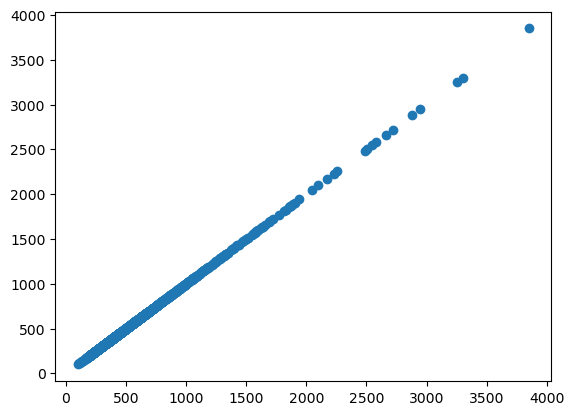

In [28]:
plt.scatter(total_y_pred, total_shap)

### SHAP Results

Below is a shap summary plot:
- The x-axis is the SHAP value. Remember, SHAP values are in the same unit of your y variable. Here we have 1 unit of SHAP value interpretated as 1k dollars.
- The y axis is a ranking of the most important to the least important vairable from top to bottom. The importance is measured by the average absolute SHAP value. Here UTM_Y (the UTM Y coordinate of the property location) is the most important variable. 
- The color of the dots are the features values with high value in red and low value in blue.
- From the color we can observe some general relationships, here I just list some examples:
    - UTM_Y: As the house is moving from south to north, the SHAP value increases, indicating houses in the northern Seattle are more expensive than houses in southern Seattle.
    - Grade: As grade increases (blue to red), SHAP value increases (left to right), indicating grade and grade's SHAP value have a positive relationship, i.e. higher-grade property will have higher property price.
    - Waterfront: since this is a binary variable, blue will be 0 (w/o waterfront) and red will be 1 (w waterfront) so property with waterfont (red dots) show they increase property price by ~150k dollars.
    - You can extrapolate these observations for other features.

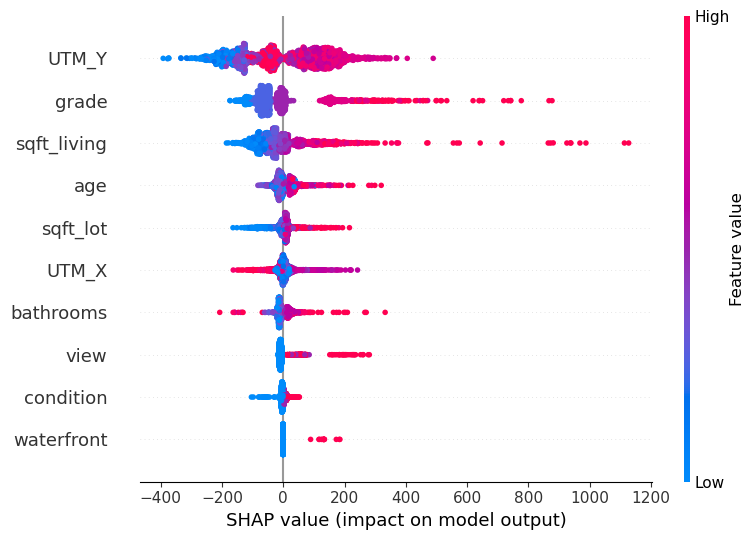

In [29]:
shap.summary_plot(shap_values, X)

Due to the local nature of SHAP values, we can observe how housing attributes determine the price for each individual house. The notation f(x) represents the model's predicted value for a house, while E(f(x)) denotes the average predicted house value. 


A feature colored red indicates a positive contribution, and one colored blue signifies a negative contribution to the difference between the predicted house price and the average predicted house price for the entire Seattle area. These SHAP values explain why the price of a certain house is higher, lower, or similar to the average house price.

This is how the prediction is made for House A

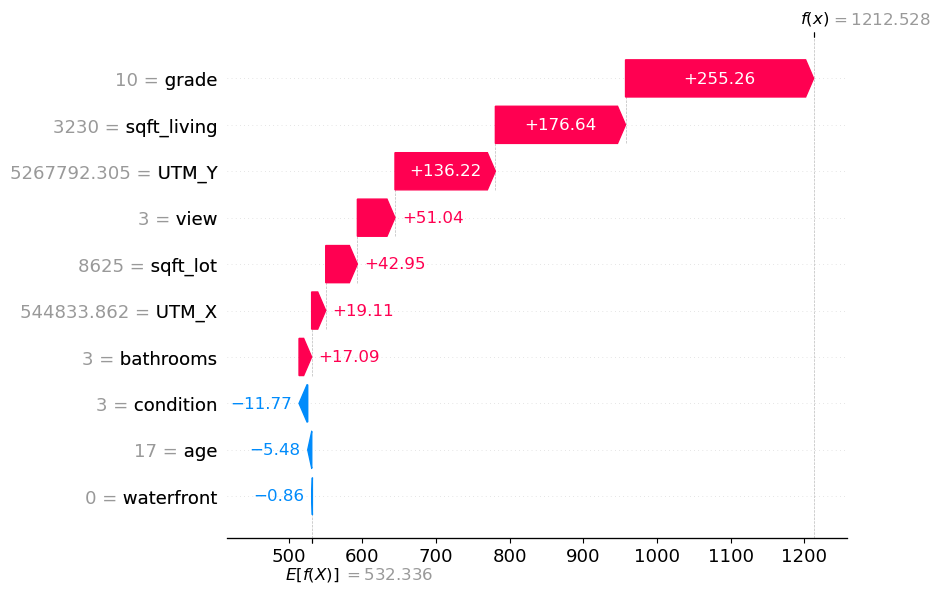

In [30]:
shap.plots.waterfall(shap_values[0])

This is how the prediction is made for House B

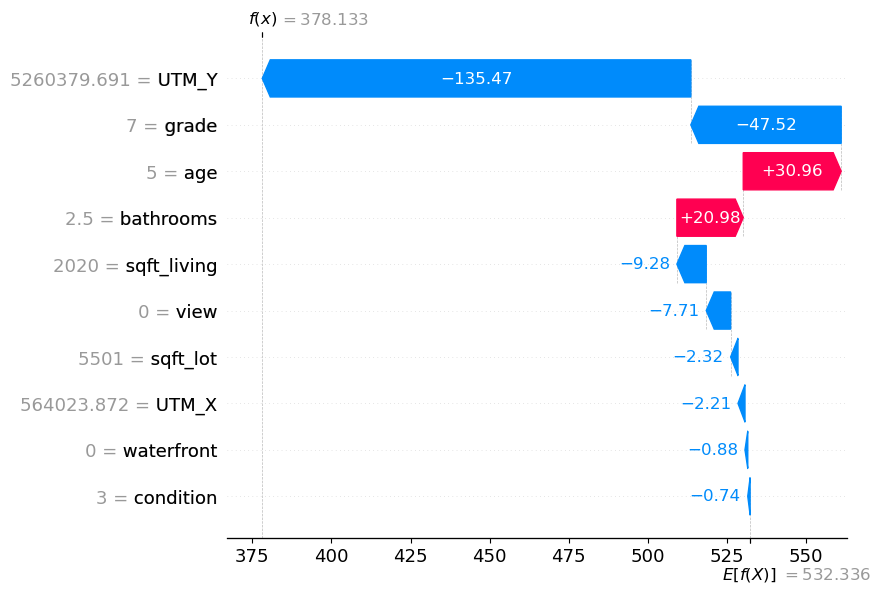

In [31]:
shap.plots.waterfall(shap_values[1])

Next we can plot partial dependence plots which each shows the relatipnship between the feature and its impact/contribution to the house price. We can observe, the shape (lienarity/non-lienarity), magitude (value on the y-axis) and trend (positive/negative) of relationships from these plots.

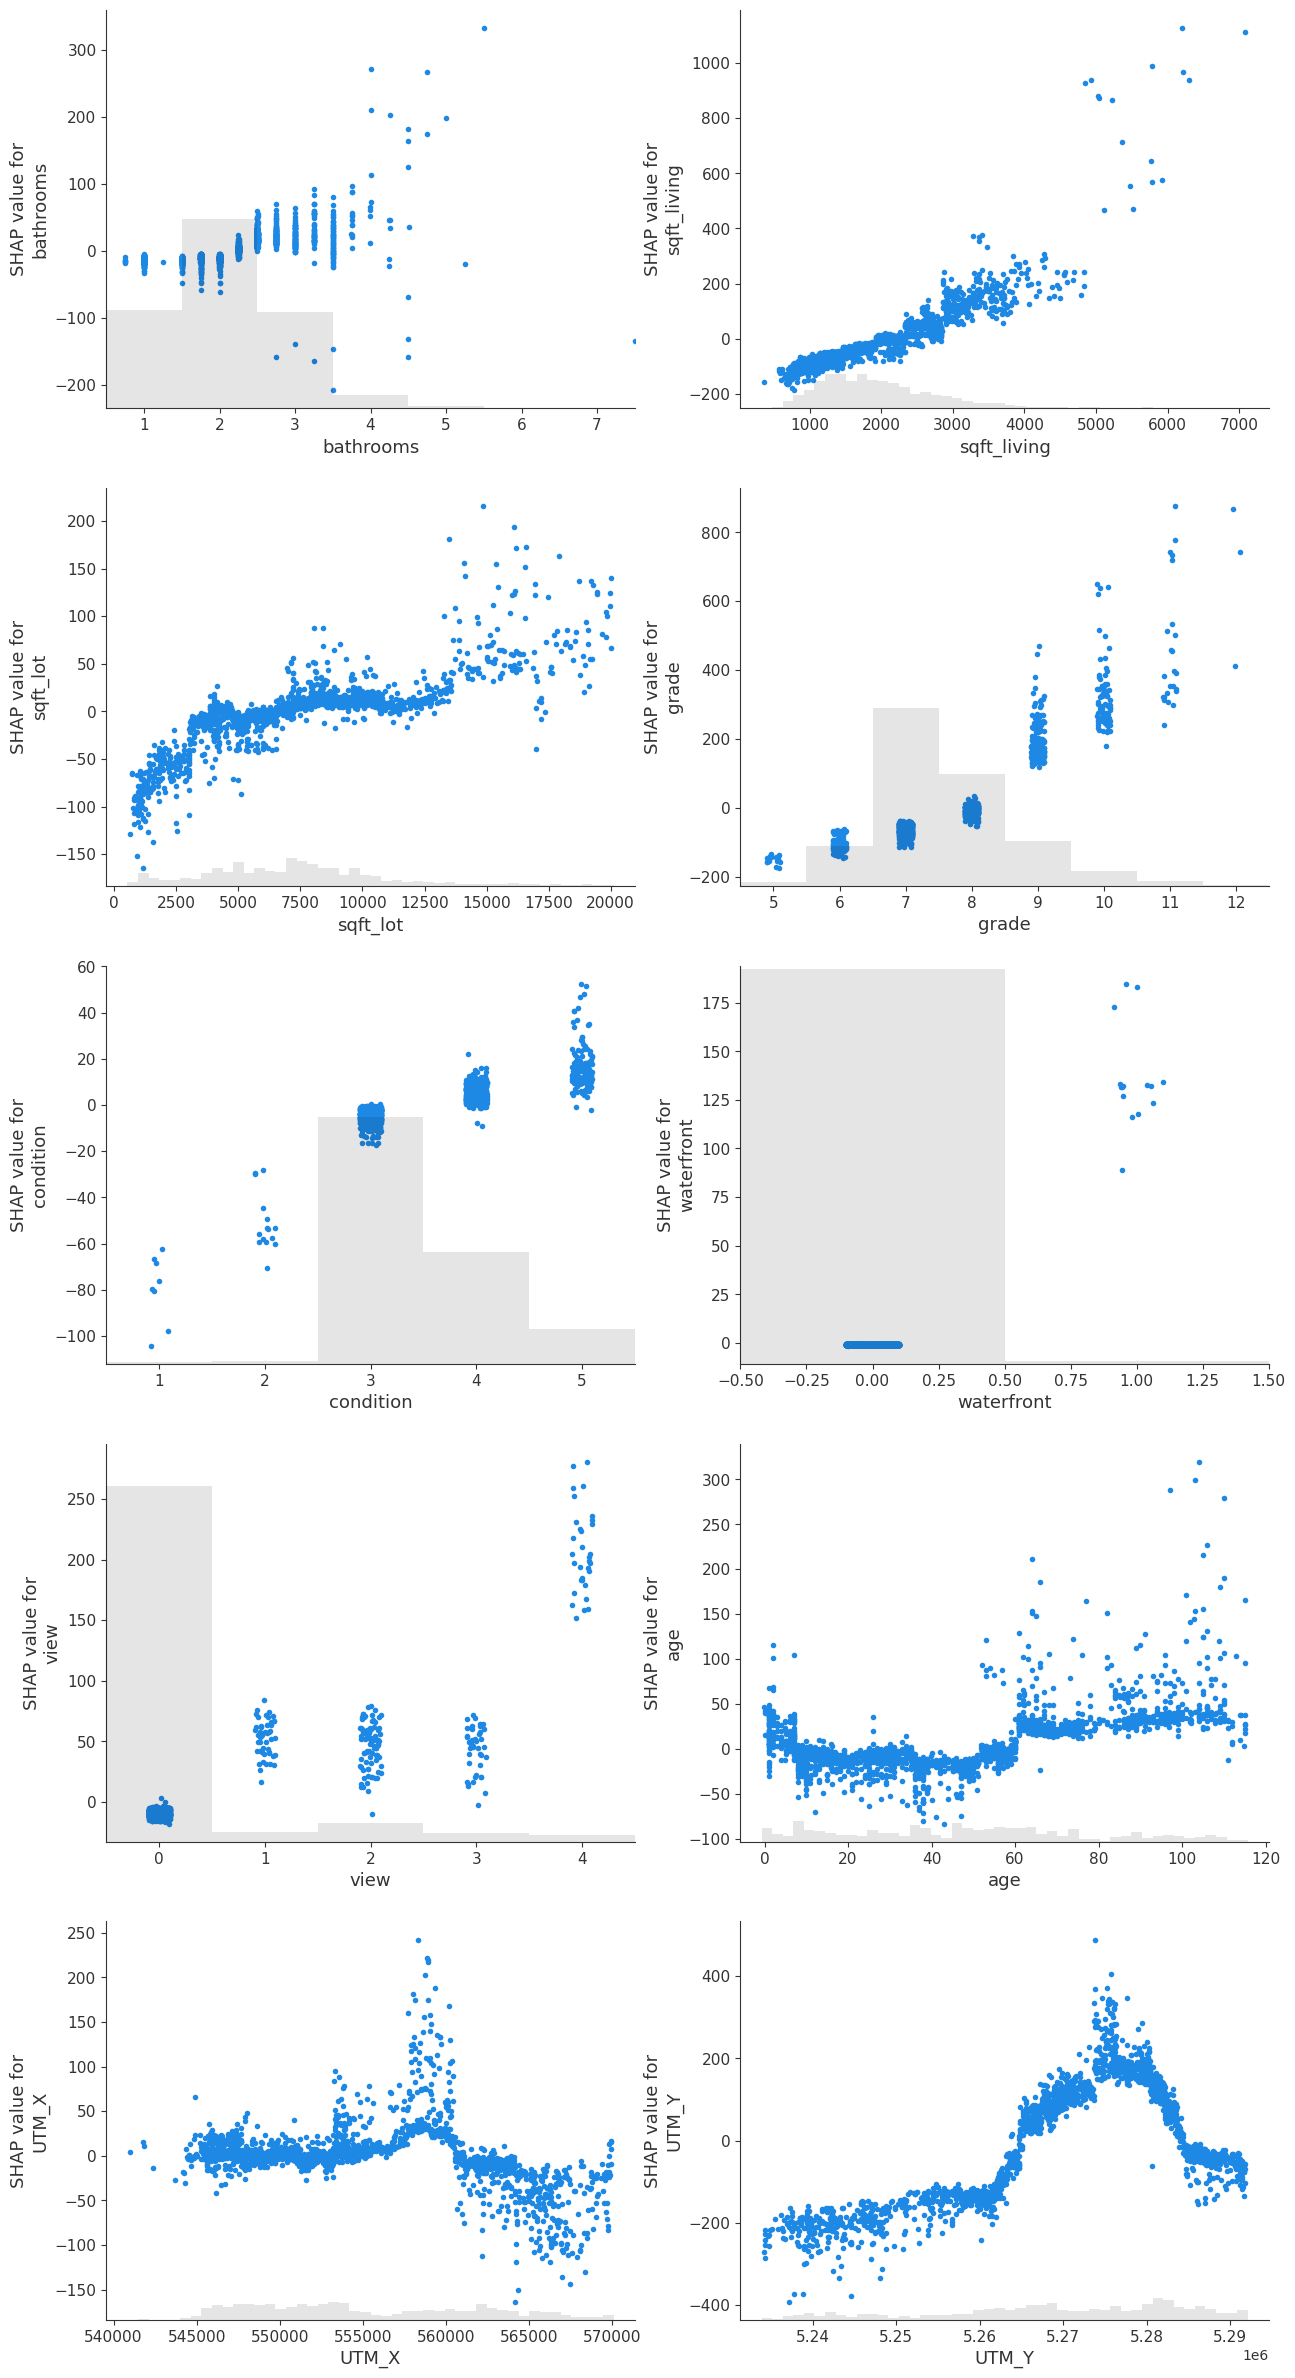

In [32]:
n_rows = 5
n_cols = 2

fig, axs = plt.subplots(n_rows, n_cols, figsize=(15, 30))  # Create a grid of subplots

for i, ax in enumerate(axs.flat):
    shap.plots.scatter(shap_values[:,i],ax=ax,show=False)

Each plot shows the relationship between the feature and the prediction: how changing the feature will change the predicted house price.